# Fitting MOSK GPs using Stan

This notebook demonstrates using Stan in python for fitting MOSK GPs.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import nutpie
import arviz as az

os.environ["TBB_CXX_TYPE"] = "clang"  # or 'gcc'

In [2]:
filename_stub = "D2-Q1-seed2727-n100-mcar0.2-sigma0.1"

D = 2
Q = 1

input_df = pd.read_csv(f'data/{filename_stub}-sim.csv')
input_df.head()

,t,f,y,y_se,d
0,0.000000,-0.643858,-0.528319,0.1,1
1,0.010101,-0.742705,-0.813978,0.1,1
2,0.020202,-0.807881,-0.641318,0.1,1
3,0.030303,-0.837087,-0.963527,0.1,1
4,0.050505,-0.785713,-0.790074,0.1,1


In [3]:
input_params = pd.read_table(f'data/{filename_stub}-param.tsv')
input_params

,seed,w,Sigma,mu,theta,phi
0,2727,1.01,0.35,3.61,-0.17,0
1,2727,0.96,0.27,4.70,0.08,0


In [4]:
ns = input_df['d'].value_counts().to_numpy()
ns

array([83, 68])

In [5]:
compiled_model = nutpie.compile_stan_model(filename='stan/moskgp-zerophi.stan')

In [6]:
compiled_model_with_data = compiled_model.with_data(
    D=D, 
    N=input_df.shape[0],
    ns=ns,
    d=input_df['d'],
    x=input_df['t'],
    y=input_df['y'],
    y_se=input_df['y_se']
)

In [7]:
trace = nutpie.sample(
    compiled_model=compiled_model_with_data, 
    draws=1000,
    tune=500,
    chains=6,
    cores=6, 
    progress_rate=1000
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,129,0.25,127
,1500,135,0.12,15
,1500,198,0.28,15
,1500,246,0.27,31
,1500,189,0.26,15
,1500,192,0.22,22


In [8]:
az.ess(trace)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:      (w_dim_0: 2, Sigma_dim_0: 2, mu_dim_0: 2, theta_dim_0: 2)
    Coordinates:
      * w_dim_0      (w_dim_0) int64 16B 0 1
      * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
      * mu_dim_0     (mu_dim_0) int64 16B 0 1
      * theta_dim_0  (theta_dim_0) int64 16B 0 1
    Data variables:
        w            (w_dim_0) float64 16B 348.6 506.1
        Sigma        (Sigma_dim_0) float64 16B 257.4 347.6
        mu           (mu_dim_0) float64 16B 994.2 3.293e+03
        theta        (theta_dim_0) float64 16B 1.973e+03 2.19e+03
        deltaTheta   float64 8B 840.8

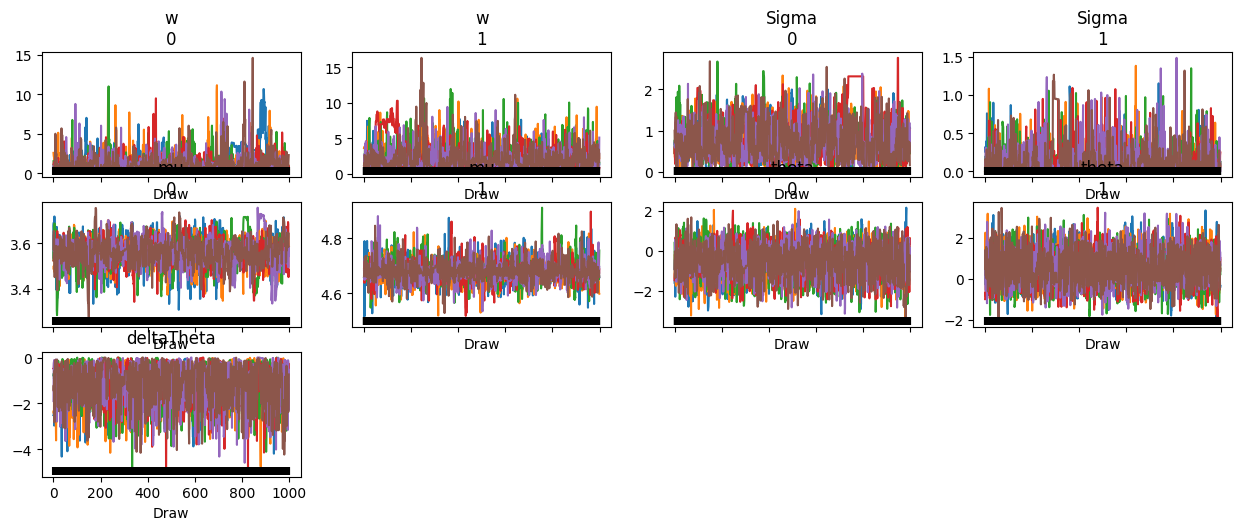

In [9]:
az.plot_trace(trace);

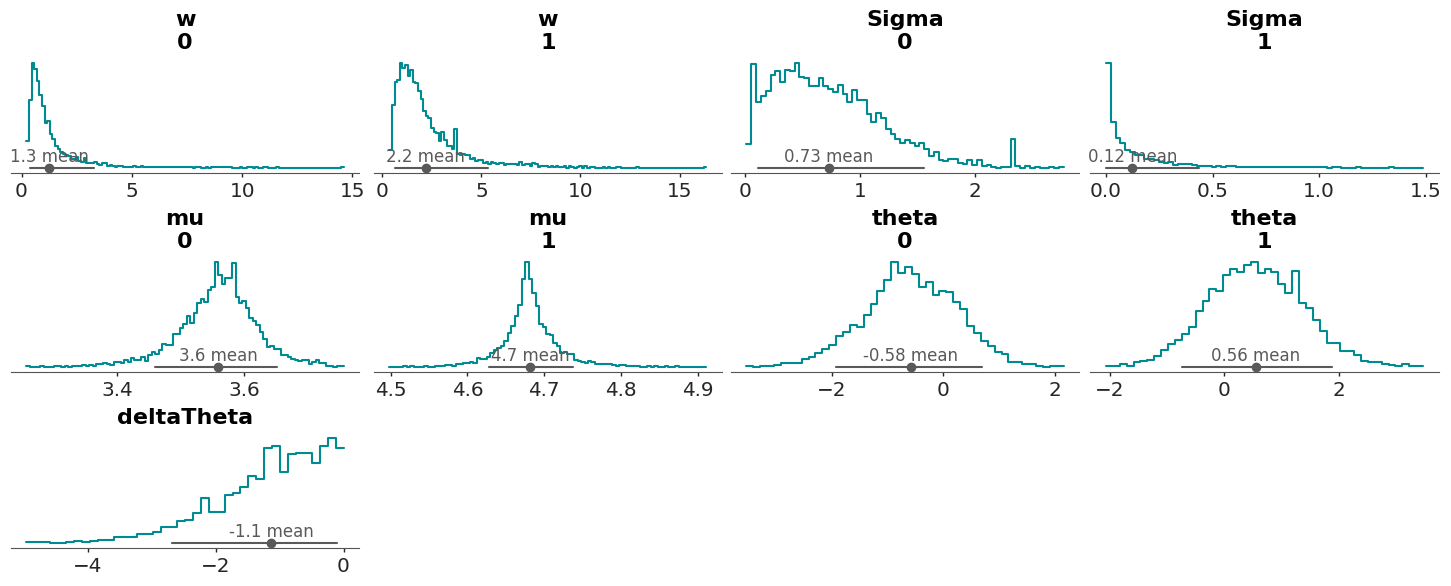

In [16]:
az.style.use("arviz-vibrant")
az.plot_dist(trace, kind="hist");

In [13]:
input_params

,seed,w,Sigma,mu,theta,phi
0,2727,1.01,0.35,3.61,-0.17,0
1,2727,0.96,0.27,4.70,0.08,0


In [12]:
trace

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:      (chain: 6, draw: 1000, w_dim_0: 2, Sigma_dim_0: 2,
│                         mu_dim_0: 2, theta_dim_0: 2)
│       Coordinates:
│         * chain        (chain) int64 48B 0 1 2 3 4 5
│         * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
│         * w_dim_0      (w_dim_0) int64 16B 0 1
│         * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
│         * mu_dim_0     (mu_dim_0) int64 16B 0 1
│         * theta_dim_0  (theta_dim_0) int64 16B 0 1
│       Data variables:
│           w            (chain, draw, w_dim_0) float64 96kB 0.7902 0.6785 ... 2.835
│           Sigma        (chain, draw, Sigma_dim_0) float64 96kB 0.6838 ... 0.09957
│           mu           (chain, draw, mu_dim_0) float64 96kB 3.688 4.722 ... 4.659
│           theta        (chain, draw, theta_dim_0) float64 96kB -1.602 ... 0.4981
│           deltaTheta   (chain, draw) float64 48kB -2.526 -2.514 ... -1.805 -0.7393
│       Attributes:
│           created_at:                 2026-08-25T01:37:43.829569+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /sample_stats
│       Dimensions:                   (chain: 6, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 48B 0 1 2 3 4 5
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 48kB 6 5 5 5 2 ... 5 5 4 4 4
│           maxdepth_reached          (chain, draw) bool 6kB False False ... False False
│           step_size                 (chain, draw) float64 48kB 0.2116 ... 0.2167
│           transformation_update_id  (chain, draw) int64 48kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 48kB 0.2287 ... 0.1975
│           mean_tree_accept          (chain, draw) float64 48kB 0.8793 ... 0.8178
│           ...                        ...
│           fisher_distance           (chain, draw) float64 48kB 606.1 776.2 ... 20.2
│           transformation_index      (chain, draw) int64 48kB 423 423 423 ... 421 421
│           diverging                 (chain, draw) bool 6kB False False ... False True
│           divergence_draw           (chain, draw) uint64 48kB 0 0 0 0 0 ... 0 0 0 1500
│           divergence_message        (chain, draw) object 48kB None ... "Error durin...
│           divergence_energy_error   (chain, draw) float64 48kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-08-25T01:37:43.833707+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.3.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /warmup_posterior
│       Dimensions:      (chain: 6, draw: 500, w_dim_0: 2, Sigma_dim_0: 2, mu_dim_0: 2,
│                         theta_dim_0: 2)
│       Coordinates:
│         * chain        (chain) int64 48B 0 1 2 3 4 5
│         * draw         (draw) int64 4kB 0 1 2 3 4 5 6 ... 493 494 495 496 497 498 499
│         * w_dim_0      (w_dim_0) int64 16B 0 1
│         * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
│         * mu_dim_0     (mu_dim_0) int64 16B 0 1
│         * theta_dim_0  (theta_dim_0) int64 16B 0 1
│       Data variables:
│           w            (chain, draw, w_dim_0) float64 48kB 0.6114 0.9017 ... 0.8944
│           Sigma        (chain, draw, Sigma_dim_0) float64 48kB 0.3505 ... 0.3832
│           mu           (chain, draw, mu_dim_0) float64 48kB 0.3704 2.481 ... 4.68
│           theta        (chain, draw, theta_dim

In [15]:
trace.to_netcdf(f'ncdf/{filename_stub}.nc')